## Question 3: Exploring Anonymized Data - Can You Find the Golden Feature?



**What is Anonymized Data?**



Anonymized data is information that has been processed to remove or obscure personally identifiable details, making it impossible to trace back to specific individuals. In credit risk modeling, features are often anonymized (e.g., `P_2`, `D_39`, `B_1`) to protect customer privacy while still enabling powerful predictive analytics.



**The Challenge:**



Credit default prediction is central to managing risk in consumer lending. American Express, the world's largest payment card issuer, uses machine learning to predict whether cardholders will default on their payments. This helps optimize lending decisions and creates a better customer experience.



You are provided with an anonymized dataset containing behavioral and profile features. Your objective is to build a classification model that predicts credit default (0 = No Default, 1 = Default).



**Your Mission:** Can you discover the 'golden feature' - the most powerful predictor hidden in this anonymized data?



Your work will be evaluated based on the completion of the following tasks:


# Part 1: Read Data



**Tasks:**



1. Read the dataset `Q3_data.csv` using `read_csv()`

2. Inspect the first few rows using `head()`

3. Display dataset information using `info()`

4. Show statistical description using `describe()`

In [ ]:
from IPython.display import clear_output

%pip install kagglehub catboost xgboost tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from tqdm import tqdm

%matplotlib inline

clear_output()

In [ ]:


# Download latest version

path = kagglehub.dataset_download("mohammad2012191/q3-ka-ai-2026")


print("Path to dataset files:", path)

Using Colab cache for faster access to the 'q3-ka-ai-2026' dataset.
Path to dataset files: /kaggle/input/q3-ka-ai-2026


In [ ]:
# Task 1: Write your code here:

csv_path = os.path.join(path, "Q3_data.csv")

df = pd.read_csv(csv_path)
df.head()

,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,Target
0,0.938469,0,0.008724,1.006838,0.009228,0.124035,0.0,0.004709,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.000610,0.0,0
1,0.929122,13,0.025782,1.002647,0.005515,0.089799,0.0,0.005830,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.000027,0.0,0
2,0.876615,0,0.001472,0.810796,0.005955,NaN,0.0,0.004826,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.002738,0.0,0
3,0.567442,9,0.070311,0.812053,0.004228,0.407420,0.0,0.010927,NaN,0.006633,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.001873,0.0,0
4,0.936842,0,0.003433,0.818691,0.007243,0.166190,0.0,0.005927,NaN,0.061963,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.003867,0.0,0


In [ ]:
# Task 2: Write your code here:
df.head()

,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,Target
0,0.938469,0,0.008724,1.006838,0.009228,0.124035,0.0,0.004709,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.000610,0.0,0
1,0.929122,13,0.025782,1.002647,0.005515,0.089799,0.0,0.005830,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.000027,0.0,0
2,0.876615,0,0.001472,0.810796,0.005955,NaN,0.0,0.004826,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.002738,0.0,0
3,0.567442,9,0.070311,0.812053,0.004228,0.407420,0.0,0.010927,NaN,0.006633,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.001873,0.0,0
4,0.936842,0,0.003433,0.818691,0.007243,0.166190,0.0,0.005927,NaN,0.061963,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.003867,0.0,0


In [ ]:
# Task 3: Write your code here:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 189 entries, P_2 to Target
dtypes: float64(148), int64(41)
memory usage: 28.8 MB


In [ ]:
# Task 4: Write your code here:

df.describe()

,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,Target
count,19227.000000,20001.000000,20001.000000,19913.000000,2.000100e+04,16142.000000,19913.000000,1.991300e+04,4846.000000,12372.000000,...,568.000000,568.000000,17892.000000,18692.000000,17892.000000,3143.000000,17892.000000,1.869000e+04,17892.000000,20001.000000
mean,0.657518,4.002250,0.111889,0.656950,5.717425e-02,0.220882,0.043126,1.032376e-01,0.190099,0.146987,...,0.010563,0.336268,0.175665,0.018778,0.162053,0.389692,0.175497,5.278575e-02,0.606696,0.263437
std,0.229293,8.047524,0.200363,0.376335,1.812706e-01,0.174875,0.173998,2.064031e-01,0.249012,0.194166,...,0.102324,0.539078,0.380546,0.135744,0.351676,0.232501,0.380403,1.841938e-01,2.005962,0.440508
min,-0.265757,0.000000,-0.079196,0.000024,8.755637e-08,-0.163072,0.000000,1.323113e-07,-0.000226,0.000034,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.005664,0.000000,8.393200e-07,0.000000,0.000000
25%,0.485759,0.000000,0.008534,0.216182,2.792879e-03,0.130907,0.000000,4.528223e-03,0.038209,0.042283,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.206377,0.000000,2.741387e-03,0.000000,0.000000
50%,0.680687,0.000000,0.028057,0.814791,5.587010e-03,0.166068,0.000000,8.630981e-03,0.121902,0.086722,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.389914,0.000000,5.481348e-03,0.000000,0.000000
75%,0.856405,5.000000,0.110502,1.001569,8.260199e-03,0.256267,0.000000,8.495419e-02,0.253785,0.175953,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.548646,0.000000,8.288856e-03,0.000000,1.000000
max,1.009957,181.000000,1.324053,1.009997,2.255852e+00,1.854302,3.940222,1.395451e+00,4.181061,3.136848,...,1.000000,4.000000,1.000000,1.000000,1.244915,1.793520,1.000000,1.342693e+00,47.000000,1.000000


# Part 2: Data Cleaning



**Tasks:**



Inspect and fix the following when needed:



1. **Handle missing values appropriately**

2. **Check and remove duplicates** if any exist

3. **Encode categorical variables** if needed

4. **Apply feature scaling** to numerical features (Use StandardScaler)

5. **Check for target imbalance and state if it is imbalanced or not**

In [79]:
# Task 1: Write your code here:


missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct.head(10)


threshold = 0
cols_to_drop = missing_pct[missing_pct > threshold].index
df = df.drop(columns=cols_to_drop)



In [80]:
# Task 2: Write your code here:

def check_duplicates(df):
  duplicates = df.duplicated().sum()
  print(f"Number of Duplicate Samples: {duplicates}")
  if duplicates > 0:
    print("Dropping Duplicates...")
    df.drop_duplicates(inplace=True)
    print("Duplicates Dropped.")
  else:
    print("No Duplicate Samples Found.")

check_duplicates(df)

Number of Duplicate Samples: 0
No Duplicate Samples Found.


In [81]:
# Task 3: Write your code here:

#There is no categorical column here so there is no need of encoding


In [82]:
# Task 4: Write your code here:

from sklearn.preprocessing import StandardScaler

features = df.columns.drop("Target")  # DON'T SCALE THE TARGET

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])
df.head()



,D_39,B_1,R_1,B_4,B_5,R_2,D_47,B_7,D_51,B_9,...,R_25,D_96,S_26,B_36,B_37,B_40,D_127,B_41,R_28,Target
0,-0.497339,-0.514898,-0.264509,-0.364111,0.151148,-0.170188,0.580560,-0.527986,5.073314,-0.615105,...,-0.044765,-0.173579,-0.136826,0.250022,-0.534379,0.099690,3.194533,-0.115075,-0.029166,0
1,1.118105,-0.429765,-0.284993,-0.672591,-0.006635,-0.170188,-0.004347,-0.639383,0.857170,-0.617627,...,-0.044765,-0.173579,-0.125390,-0.036641,-0.437678,-0.348253,-0.313035,-0.115075,-0.029166,0
2,-0.497339,-0.551095,-0.282565,-0.672591,-0.110536,-0.170188,-0.267627,-0.652786,-0.548212,-0.632841,...,-0.044765,-0.173579,-0.124642,0.049720,-0.524061,-0.381452,-0.313035,-0.115075,-0.029166,0
3,0.621045,-0.207516,-0.292093,-0.240719,-0.118659,-0.170188,0.035253,0.267212,-0.548212,-0.542149,...,-0.044765,-0.173579,-0.125285,-0.319519,-0.190663,0.366544,-0.313035,-0.115075,-0.029166,0
4,-0.497339,-0.541305,-0.275461,-0.425807,-0.113689,-0.170188,0.336372,-0.625896,0.857170,-0.625770,...,-0.044765,-0.173579,-0.138945,-0.251353,-0.530241,0.051194,-0.313035,-0.115075,-0.029166,0


Target Distribution:
Target
0    0.736563
1    0.263437
Name: proportion, dtype: float64


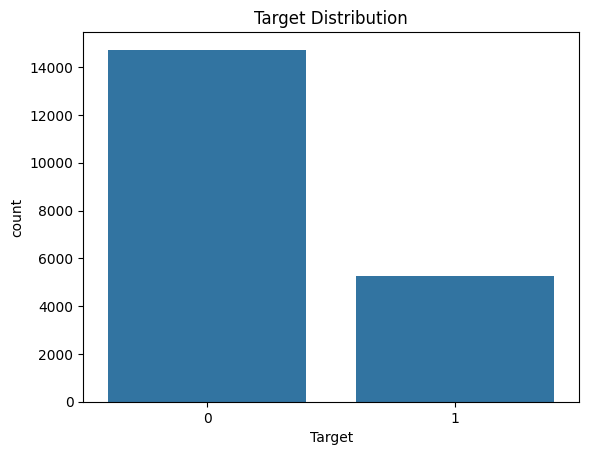

In [83]:
# Task 5: Write your code here:

def check_target_imbalance(df, target_column):
  print("Target Distribution:")
  print(df[target_column].value_counts(normalize=True))
  sns.countplot(x=df[target_column])
  plt.title("Target Distribution")
  plt.show()

check_target_imbalance(df, "Target")

We can see our data is imbalanced. We will use StratifiedKFold and focus on F1-score.

# Part 3: Modeling



**Tasks:**



1. Split the dataset into features (X) and target (y)

2. Use the correct split: **KFold** OR **StratifiedKFold**

3. Train a **CatBoostClassifier** model

4. Evaluate using the appropriate metric only (Accuracy vs. F1 Score).

5. Print the averaged score across all folds

In [84]:
# Task 1: Write your code here:

X = df.drop("Target", axis=1).astype(float)
y = df['Target'].astype(float)

In [85]:
# Import models

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold

In [86]:
sklearn_models = {
  "CatBoost": CatBoostClassifier(
      verbose=0,
      n_estimators=320,
      max_depth=4
  )
}

In [87]:
all_results = {}

for name in sklearn_models:
  all_results[name] = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

In [88]:
n_splits = 5 # K

# Stratified 5-Fold Cross-Validation, shuffled
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [89]:
for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  # 1. Split data
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  # 2. Train & Validate sklearn models
  for model_name, model in sklearn_models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train) # train
    y_pred = model.predict(X_test) # validate

    # 3. Save metrics for that model in this fold
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    all_results[model_name]['accuracy'].append(accuracy)
    all_results[model_name]['precision'].append(precision)
    all_results[model_name]['recall'].append(recall)
    all_results[model_name]['f1'].append(f1)


Fold 1/5
Training CatBoost...

Fold 2/5
Training CatBoost...

Fold 3/5
Training CatBoost...

Fold 4/5
Training CatBoost...

Fold 5/5
Training CatBoost...


In [90]:
for model_name in all_results:
  print(f"\n{model_name}:")
  print(f"  Accuracy:  {np.mean(all_results[model_name]['accuracy']):.4f}")
  print(f"  Precision: {np.mean(all_results[model_name]['precision']):.4f}")
  print(f"  Recall:    {np.mean(all_results[model_name]['recall']):.4f}")
  print(f"  F1-Score:  {np.mean(all_results[model_name]['f1']):.4f}")


CatBoost:
  Accuracy:  0.8233
  Precision: 0.6831
  Recall:    0.6136
  F1-Score:  0.6464


# Part 4: Find the Golden Feature!



**Tasks:**



1. Plot feature importance from your trained model

2. Identify and print the name of the most important feature (the 'golden feature')

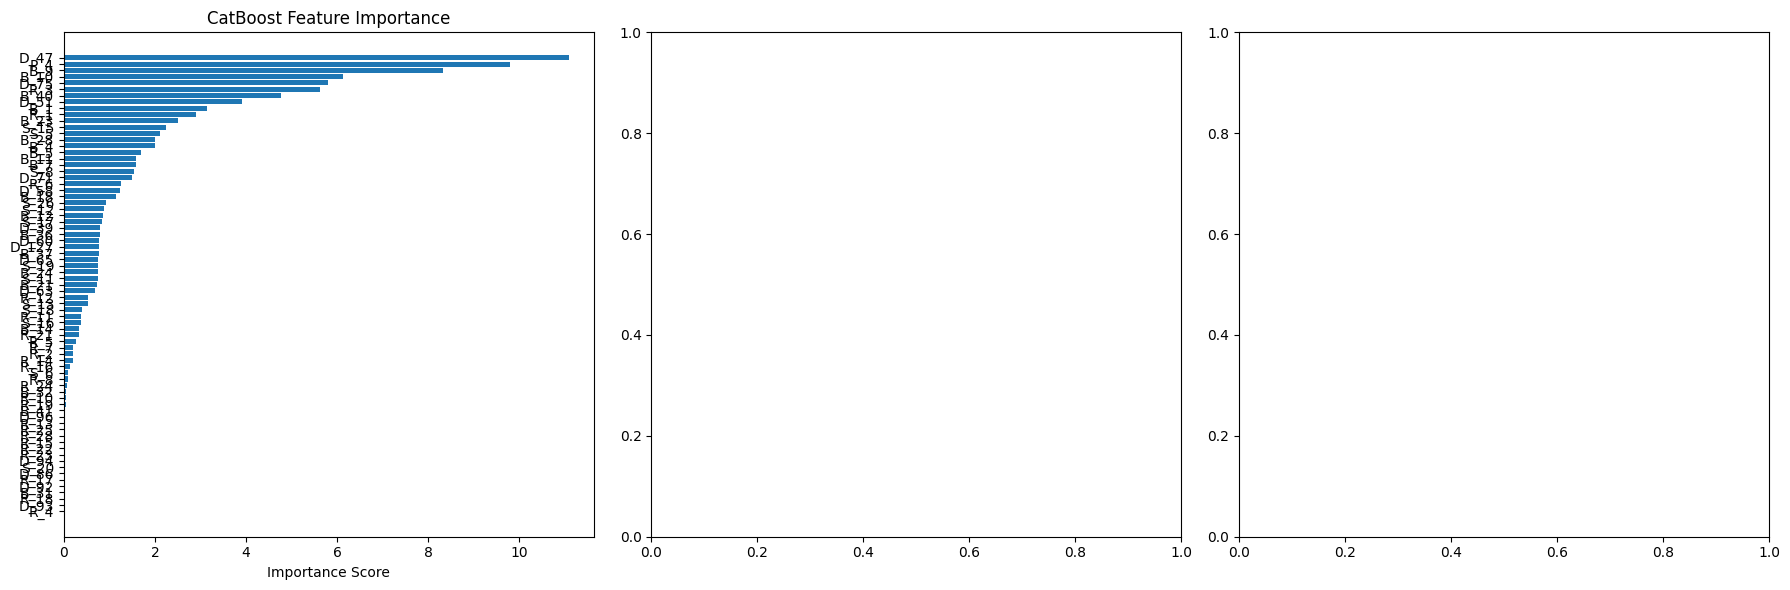

In [91]:
# Task 1: Write your code here:

# Gather importances from the models (from the last fold)
importances = {}

importances['CatBoost'] = sklearn_models['CatBoost'].feature_importances_

# Create a 1x3 plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()
features = X.columns

for i, (model_name, imp) in enumerate(importances.items()):
  # Sort features by importance for a cleaner plot
  sorted_idx = np.argsort(imp)

  ax = axes[i]
  ax.barh(features[sorted_idx], imp[sorted_idx])
  ax.set_title(f"{model_name} Feature Importance")
  ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

In [92]:
# Task 2: Write your code here:

avg_importance = np.mean(np.vstack(list(importances.values())), axis=0)

golden_idx = np.argmax(avg_importance)
golden_feature = X.columns[golden_idx]

print(f"Overall golden feature: {golden_feature}")


Overall golden feature: D_47


# Part 5: Bonus - Retrain with Golden Feature Only



**Task:**



Now that you've found the golden feature, let's see how powerful it really is!



Retrain your CatBoostClassifier using **ONLY the golden feature** and compare its performance to the full model:



1. Create new X with only the golden feature

2. Run the same KFold loop with this single feature

3. Print and compare the accuracy with the full model

In [93]:
# Task Bonus: Write your code here:

import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

# --- set this to your golden feature name ---
GOLDEN_FEATURE = "your_golden_feature_name_here"

# 1) Create new X with only the golden feature
X_golden = X[[GOLDEN_FEATURE]].copy()

# 2) Run the same KFold loop with this single feature
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # match your original settings!

gold_fold_acc = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_golden), 1):
    X_tr, X_va = X_golden.iloc[tr_idx], X_golden.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=42,
        verbose=False,
        # keep the same hyperparams you used for the full model:
        # iterations=..., depth=..., learning_rate=..., l2_leaf_reg=..., etc.
    )

    model.fit(X_tr, y_tr)

    preds = model.predict(X_va)
    acc = accuracy_score(y_va, preds)
    gold_fold_acc.append(acc)

gold_mean = float(np.mean(gold_fold_acc))
gold_std = float(np.std(gold_fold_acc))
